In [217]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 50M; Nz = 95
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc') #***
# res='1km'; t_res='1min_95nz'; Np_str='50e6'

In [218]:
times=data['time'].values/(1e9 * 60); times=times.astype(float);
minutes=1/times[1] #1 / minutes per timestep = timesteps per minute
job_array=False;index_adjust=0
ocean_fraction=2/8

In [219]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

#####

#Import StatisticalFunctions 
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import StatisticalFunctions
from StatisticalFunctions import * # import NumericalFunctions 

In [220]:
#CL VS NONCL
################################################################

In [221]:
##########################################################
#PLOTTING

In [222]:
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] > 1)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

In [223]:
def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
all_cloudbase=min_all_cloudbase
print(f"Minimum Cloudbase is: {min_all_cloudbase}\n")

Minimum Cloudbase is: 1.2463867664337158



In [225]:
PROCESSING=False
PROCESSING=True

In [226]:
#NEEDED TO PLOT THE CORRECT DATA #*#*
data_type="Tracked_Entrainment_VMF"

In [227]:
type1='CL';type2='nonCL'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
if PROCESSING==True:
    filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
elif PROCESSING==False:
    filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"]);factor=1.96
    # globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"]); factor=1
    # print(key)

In [228]:
data_type2="Tracked_Combined_Entrainment"
type1='CL';type2='nonCL'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
if PROCESSING==True:
    filePath=dir3 + f"{data_type2}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
elif PROCESSING==False:
    filePath=dir3 + f"{data_type2}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)
        print(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"]);factor=1.96
    # globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"]); factor=1

CL_ALL_profile_array_C_TO_G
CL_ALL_profile_array_G_TO_C
CL_DEEP_profile_array_C_TO_G
CL_DEEP_profile_array_G_TO_C
CL_SHALLOW_profile_array_C_TO_G
CL_SHALLOW_profile_array_G_TO_C
nonCL_ALL_profile_array_C_TO_G
nonCL_ALL_profile_array_G_TO_C
nonCL_DEEP_profile_array_C_TO_G
nonCL_DEEP_profile_array_G_TO_C
nonCL_SHALLOW_profile_array_C_TO_G
nonCL_SHALLOW_profile_array_G_TO_C


ValueError: operands could not be broadcast together with shapes (14,) (15,) (14,) 

In [229]:
# #TESTING
# def ProfileVariance(profile,squares_profile): 
#     print(profile,squares_profile)
#     #Input Requires Three Column Array 
#     #with Sum in 1st Column, Count in 2nd Column, and Index in 3rd Column
#     #Returns 1st and 3rd Column (removing zero rows)

#     #MEAN OF SQUARES
#     #gets rid of rows that have no data
#     profile_mean1=squares_profile[ (squares_profile[:, 1] > 1)]; N=profile_mean1[:,1]
#     #divides the data column by the counter column
#     profile_mean1=np.array([profile_mean1[:, 0] / profile_mean1[:, 1], profile_mean1[:, 2]]).T 
#     # print(f"Mean of Squares Profile is \n{profile_mean1}") #TESTING

#     #SQUARE OF MEAN
#     #gets rid of rows that have no data
#     profile_mean2=profile[ (profile[:, 1] > 1)]; 
#     #divides the data column by the counter column
#     profile_mean2=np.array([profile_mean2[:, 0] / profile_mean2[:, 1], profile_mean2[:, 2]]).T 
#     profile_mean2[:,0]**=2
#     # print(f"Mean Profile Squared is \n{profile_mean2}") #TESTING

#     #SUBTRACTING THE TWO
#     profile_mean=profile_mean1.copy()
#     profile_mean[:,0]-=profile_mean2[:,0]
#     # print(f"Variance Profile is \n{profile_mean}") #TESTING
#     return profile_mean,N
    
# def ProfileStandardDeviation(profile,squares_profile): 
#     [variance,N]=ProfileVariance(profile,squares_profile)
#     standard_deviation=variance.copy()
#     standard_deviation[:,0]**=(0.5)
#     return standard_deviation
    
# def ProfileStandardError(profile,squares_profile): 
#     [variance,N]=ProfileVariance(profile,squares_profile)
#     standard_error=variance.copy()
#     standard_error[:,0]/=(N-1)
#     standard_error[:,0]**=(0.5)

#     # standard_error2=variance.copy()
#     # standard_error2[:,0]*=N/(N-1)/N
#     # standard_error2[:,0]**=(0.5)
#     # print(standard_error2==standard_error)
#     return standard_error

In [230]:
def PlotSE(ax, profile, SE_profile, color, factor, switch=1, alpha=0.1):
    ax.fill_betweenx(profile[:, -1],
                     profile[:, 0] - factor * SE_profile[:, 0] * switch,
                     profile[:, 0] + factor * SE_profile[:, 0] * switch,
                     color=color, alpha=alpha)
def PlotProfiles(ax,type1,type2,type3,type4):
    lw = 1
    cutoff_height = 100
    z_cutoff = np.where(globals()[f"{type1}_ALL_profile_array_{type3}_{type4}"][:, 2] <= cutoff_height)[0][-1]

    profiles = [
        (globals()[f"{type1}_ALL_profile_array_{type3}_{type4}"], globals()[f"{type1}_SHALLOW_profile_array_{type3}_{type4}"], globals()[f"{type1}_DEEP_profile_array_{type3}_{type4}"], type1),
        (globals()[f"{type2}_ALL_profile_array_{type3}_{type4}"], globals()[f"{type2}_SHALLOW_profile_array_{type3}_{type4}"], globals()[f"{type2}_DEEP_profile_array_{type3}_{type4}"], type2)
    ]

    SE_profiles = [
        (globals()[f"{type1}_ALL_profile_array_{type3}_{type4}_SE"], globals()[f"{type1}_SHALLOW_profile_array_{type3}_{type4}_SE"], globals()[f"{type1}_DEEP_profile_array_{type3}_{type4}_SE"], type1),
        (globals()[f"{type2}_ALL_profile_array_{type3}_{type4}_SE"], globals()[f"{type2}_SHALLOW_profile_array_{type3}_{type4}_SE"], globals()[f"{type2}_DEEP_profile_array_{type3}_{type4}_SE"], type2)
    ]

    for ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, label),
     (ALL_SE_array, SHALLOW_SE_array, DEEP_SE_array, _)) in zip(profiles, SE_profiles):

        ALL_profile = averaged_profiles(ALL_profile_array)[:z_cutoff]
        SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)[:z_cutoff]
        DEEP_profile = averaged_profiles(DEEP_profile_array)[:z_cutoff]

        if label == type1:
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='solid',color='black', label=f'ALL ({type1})', lw=lw)
            PlotSE(ax,ALL_profile,ALL_SE_array,color='black',factor=factor)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='solid', color='green', label=f'SHALLOW ({type1})', lw=lw)
            PlotSE(ax,SHALLOW_profile,SHALLOW_SE_array,color='green',factor=factor)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='solid',color='blue', label=f'DEEP ({type1})', lw=lw)
            PlotSE(ax,DEEP_profile,DEEP_SE_array,color='blue',factor=factor)
        else:
            ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label=f'ALL ({type2})', lw=lw)
            PlotSE(ax,ALL_profile,ALL_SE_array,color='black',factor=factor)
            ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label=f'SHALLOW ({type2})', lw=lw)
            PlotSE(ax,SHALLOW_profile,SHALLOW_SE_array,color='green',factor=factor)
            ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label=f'DEEP ({type2})', lw=lw)
            PlotSE(ax,DEEP_profile,DEEP_SE_array,color='blue',factor=factor)

        apply_scientific_notation([ax])

    ax.set_ylim(0, 3)
    ax.set_xlabel('x-axis label')  # Update label if needed
    ax.set_ylabel('z (km)')
    ax.grid(True)
    ax.axvline(0, linestyle='dashed', color='grey', zorder=-10)
    ax.axhline(all_cloudbase, color='purple', linestyle='dashed')
    ax.legend(fontsize=8)

def PlotTwo(ax, type1, type2, factor=1):
    lw = 1
    cutoff_height = 100

    z_cutoff = np.where(CL_ALL_profile_array_G_TO_C[:, 2] <= cutoff_height)[0][-1]

    # Define profile arrays
    profiles = [
        (CL_ALL_profile_array_G_TO_C, CL_SHALLOW_profile_array_G_TO_C, CL_DEEP_profile_array_G_TO_C, type1),
        (nonCL_ALL_profile_array_G_TO_C, nonCL_SHALLOW_profile_array_G_TO_C, nonCL_DEEP_profile_array_G_TO_C, type2)
    ]

    # Define standard error arrays
    SE_profiles = [
        (CL_ALL_profile_array_G_TO_C_SE, CL_SHALLOW_profile_array_G_TO_C_SE, CL_DEEP_profile_array_G_TO_C_SE, type1),
        (nonCL_ALL_profile_array_G_TO_C_SE, nonCL_SHALLOW_profile_array_G_TO_C_SE, nonCL_DEEP_profile_array_G_TO_C_SE, type2)
    ]

    for ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, label),
         (ALL_SE_array, SHALLOW_SE_array, DEEP_SE_array, _)) in zip(profiles, SE_profiles):

        ALL_profile = averaged_profiles(ALL_profile_array)[:z_cutoff]
        SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)[:z_cutoff]
        DEEP_profile = averaged_profiles(DEEP_profile_array)[:z_cutoff]

        linestyle = 'solid' if label == type1 else 'dashed'

        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle=linestyle, color='black', label=f'ALL ({label})', lw=lw)
        PlotSE(ax, ALL_profile, ALL_SE_array, color='black', factor=factor)

        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle=linestyle, color='green', label=f'SHALLOW ({label})', lw=lw)
        PlotSE(ax, SHALLOW_profile, SHALLOW_SE_array, color='green', factor=factor)

        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle=linestyle, color='blue', label=f'DEEP ({label})', lw=lw)
        PlotSE(ax, DEEP_profile, DEEP_SE_array, color='blue', factor=factor)

        apply_scientific_notation([ax])

    # Final plot settings
    ax.set_ylim(0, 3)
    ax.set_xlabel('x-axis label')  # Replace with actual label
    ax.set_ylabel('z (km)')
    ax.grid(True)
    ax.axvline(0, linestyle='dashed', color='grey', zorder=-10)
    ax.axhline(all_cloudbase, color='purple', linestyle='dashed')
    ax.legend(fontsize=8)
    plt.tight_layout()

    return ax

In [231]:
#DIFFERENCE PLOT
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

def compute_diff(group, var, cat1='DEEP', cat2='SHALLOW'):
    profile1 = globals()[f"{group}_{cat1}_profile_array_{var}_C"]
    profile2 = globals()[f"{group}_{cat2}_profile_array_{var}_C"]
    globals()[f"{group}_diff_{var.lower()}"] = average_difference(profile1, profile2)

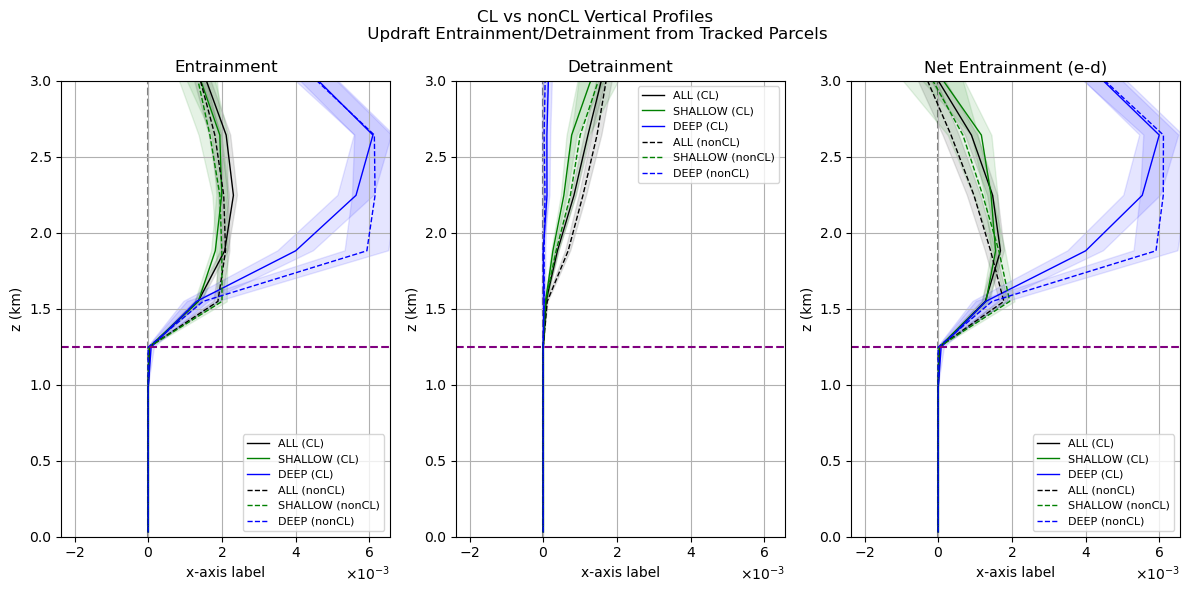

In [232]:
#PLOTTING
# type4='general'
type4='cloudy'

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Run the plotting function separately for each axis
PlotProfiles(ax1,type1=type1,type2=type2,type3='E',type4=type4[0].upper())
PlotProfiles(ax2,type1=type1,type2=type2,type3='D',type4=type4[0].upper())
PlotProfiles(ax3,type1=type1,type2=type2,type3='NET',type4=type4[0].upper())
MatchAxisLimits([ax1,ax2,ax3],dim='x')

# Optional: customize titles for each panel
ax1.set_title('Entrainment')
ax2.set_title('Detrainment')
ax3.set_title('Net Entrainment (e-d)')

plt.suptitle(f'{type1} vs {type2} Vertical Profiles\n Updraft Entrainment/Detrainment from Tracked Parcels')
plt.tight_layout()
plt.show()


ValueError: operands could not be broadcast together with shapes (15,) (14,) 

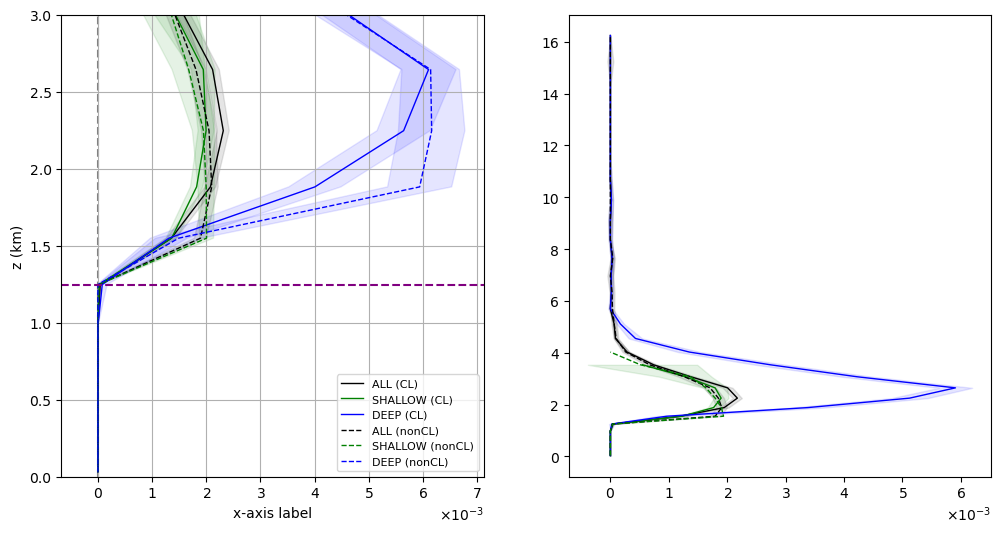

In [233]:
#PLOTTING
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1,2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Run the plotting function separately for each axis
PlotProfiles(ax1,type1=type1,type2=type2,type3='E',type4=type4[0].upper())
PlotTwo(ax2,type1=type1,type2=type2)
MatchAxisLimits([ax1,ax2],dim='x')

# Optional: customize titles for each panel
ax1.set_title('nonCloudy to Cloudy Entrainment')
ax2.set_title('General to Cloudy Entrainment')
plt.suptitle(f'{type1} vs {type2} Vertical Profiles\n Updraft')
plt.tight_layout()

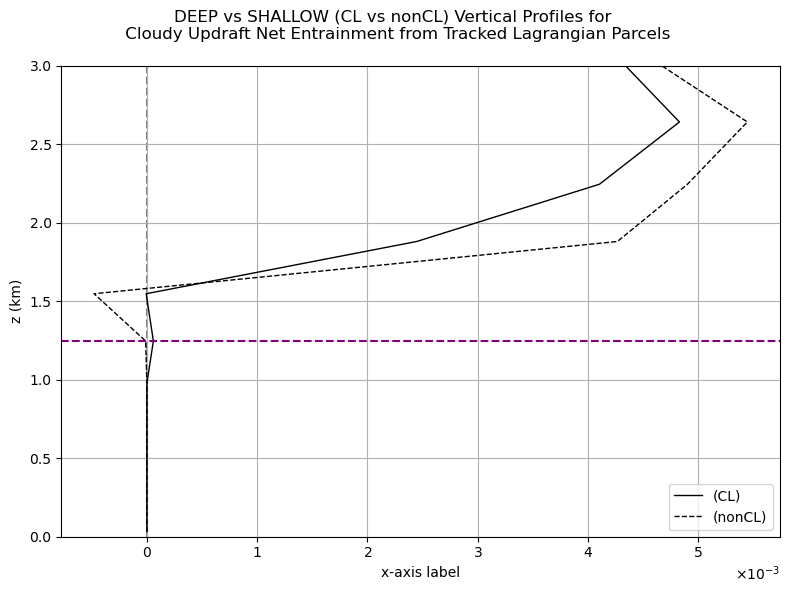

In [273]:
var = 'NET'
compute_diff('CL', var)
compute_diff('nonCL', var) 


#REDUCING FOR CONFERENCE FIGURE
import matplotlib.pyplot as plt
lw=1

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (CL_diff_net,  'net', 'CL Diff'),
    (nonCL_diff_net,  'net', 'nonCL Diff'),
]

cutoff_height=100
# cutoff_height=7.5
# cutoff_height=2
z_cutoff=np.where(CL_ALL_profile_array_NET_C[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

# Set up the figure
fig = plt.figure(figsize=(8, 6))

# Create a single axis for all profiles
ax = fig.add_subplot(111)

# Loop through profiles for CL and nonCL
for i, (ALL_profile, xlabel, CLlabel) in enumerate(profiles):

    #CUT BELOW CERTAIN Z
    ALL_profile=ALL_profile[:z_cutoff]

    # Plot the profile for ALL (CL and nonCL) on top of each other
    if CLlabel == 'CL Diff':
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='(CL)',lw=lw)
    else:
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='(nonCL)',lw=lw)
    apply_scientific_notation([ax])

if type3 in ['general','cloudy']:
    ax.set_ylim(0,3)

# Add labels and title
ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
ax.set_ylabel('z (km)')
ax.grid(True)

ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)

# Show legend
ax.legend()

#MEAN CLOUD BASE
ax.axhline(all_cloudbase,color='purple',linestyle='dashed')

# Set up the main title and adjust layout
plt.suptitle(f'DEEP vs SHALLOW (CL vs nonCL) Vertical Profiles for \n {type3.title()} Updraft Net Entrainment from Tracked Lagrangian Parcels')
plt.tight_layout()

# Show plot
plt.show()




In [274]:
##########################################################################################
#SBZ vs nonSBZ Tracked Entrainment Profiles

In [275]:
##########################################################
#PLOTTING

In [351]:
type1='SBZ';type2='nonSBZ'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"])
    # globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"])
    # print(key)

In [279]:
# data_type2="Tracked_Combined_Entrainment"
# type1='SBZ';type2='nonSBZ'
# dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# filePath=dir3 + f"{data_type2}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
# if PROCESSING==False:
#     filePath=dir3 + f"{data_type2}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}_ORIGINAL.h5"
# with h5py.File(filePath, 'r') as h5f:
#     for key in h5f.keys():
#         globals()[key] = h5f[key][:]
#         print(key)

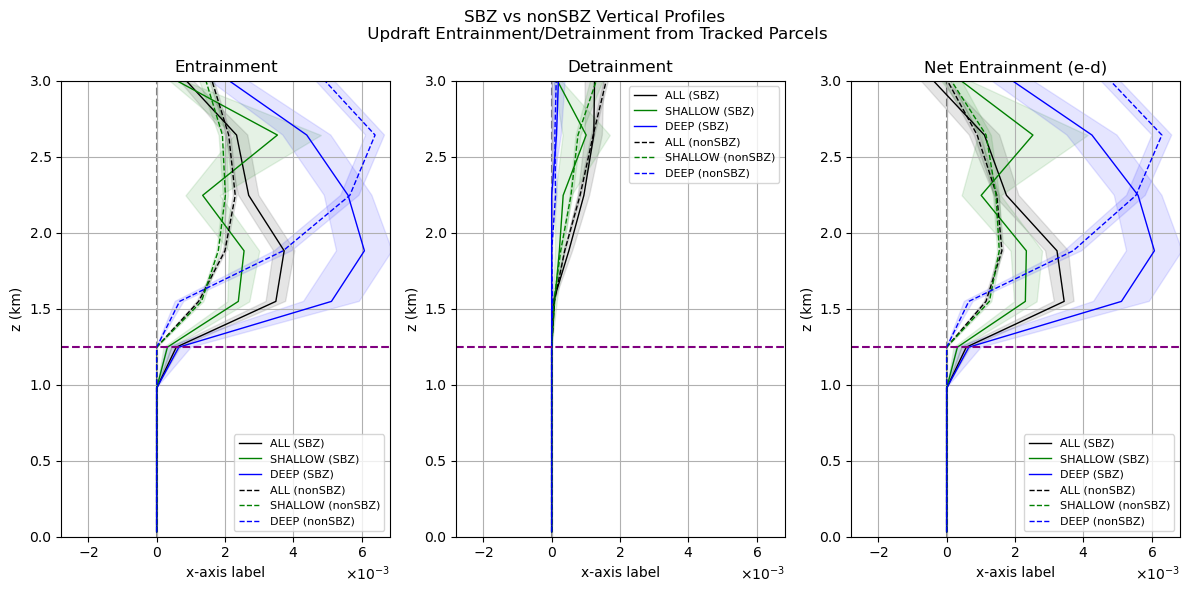

In [280]:
#PLOTTING
# type4='general'
type4='cloudy'

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Run the plotting function separately for each axis
PlotProfiles(ax1,type1=type1,type2=type2,type3='E',type4=type4[0].upper())
PlotProfiles(ax2,type1=type1,type2=type2,type3='D',type4=type4[0].upper())
PlotProfiles(ax3,type1=type1,type2=type2,type3='NET',type4=type4[0].upper())
MatchAxisLimits([ax1,ax2,ax3],dim='x')

# Optional: customize titles for each panel
ax1.set_title('Entrainment')
ax2.set_title('Detrainment')
ax3.set_title('Net Entrainment (e-d)')

plt.suptitle(f'{type1} vs {type2} Vertical Profiles\n Updraft Entrainment/Detrainment from Tracked Parcels')
plt.tight_layout()
plt.show()


In [281]:
# #PLOTTING
# fig = plt.figure(figsize=(12, 6))
# gs = fig.add_gridspec(2, 3)

# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])

# # Run the plotting function separately for each axis
# PlotProfiles(ax1,type1=type1,type2=type2,type3='e')
# PlotTwo(ax2,type1=type1,type2=type2)
# MatchAxisLimits([ax1,ax2],dim='x')

# # Optional: customize titles for each panel
# ax1.set_title('nonCloudy to Cloudy Entrainment')
# ax2.set_title('General to Cloudy Entrainment')
# plt.suptitle(f'{type1} vs {type2} Vertical Profiles\n{type3.title()} Updraft')
# plt.tight_layout()

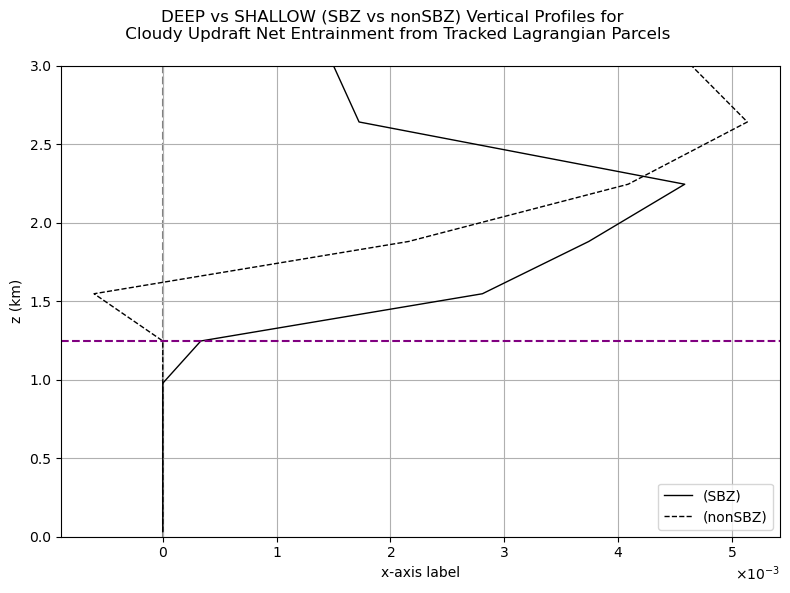

In [282]:
var = 'NET'
compute_diff('SBZ', var)
compute_diff('nonSBZ', var) 

#REDUCING FOR CONFERENCE FIGURE
import matplotlib.pyplot as plt
lw=1

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (SBZ_diff_net,  'net', 'SBZ Diff'),
    (nonSBZ_diff_net,  'net', 'nonSBZ Diff'),
]

cutoff_height=100
# cutoff_height=7.5
# cutoff_height=2
z_cutoff=np.where(SBZ_ALL_profile_array_NET_C[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

# Set up the figure
fig = plt.figure(figsize=(8, 6))

# Create a single axis for all profiles
ax = fig.add_subplot(111)

# Loop through profiles for SBZ and nonSBZ
for i, (ALL_profile, xlabel, SBZlabel) in enumerate(profiles):

    #CUT BELOW CERTAIN Z
    ALL_profile=ALL_profile[:z_cutoff]

    # Plot the profile for ALL (SBZ and nonSBZ) on top of each other
    if SBZlabel == 'SBZ Diff':
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='(SBZ)',lw=lw)
    else:
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='(nonSBZ)',lw=lw)
    apply_scientific_notation([ax])


if type3 in ['general','cloudy']:
    ax.set_ylim(0,3)

# Add labels and title
ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
ax.set_ylabel('z (km)')
ax.grid(True)

ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)

# Show legend
ax.legend()

#MEAN CLOUD BASE
ax.axhline(all_cloudbase,color='purple',linestyle='dashed')

# Set up the main title and adjust layout
plt.suptitle(f'DEEP vs SHALLOW (SBZ vs nonSBZ) Vertical Profiles for \n {type3.title()} Updraft Net Entrainment from Tracked Lagrangian Parcels')
plt.tight_layout()

# Show plot
plt.show()




In [283]:
#ColdPool
################################################################

In [266]:
########################
#PLOTTING

In [353]:
type3='general'
type3='cloudy'

type1='ColdPool';type2='SBZ'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"])
    # globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"])
    # print(key)

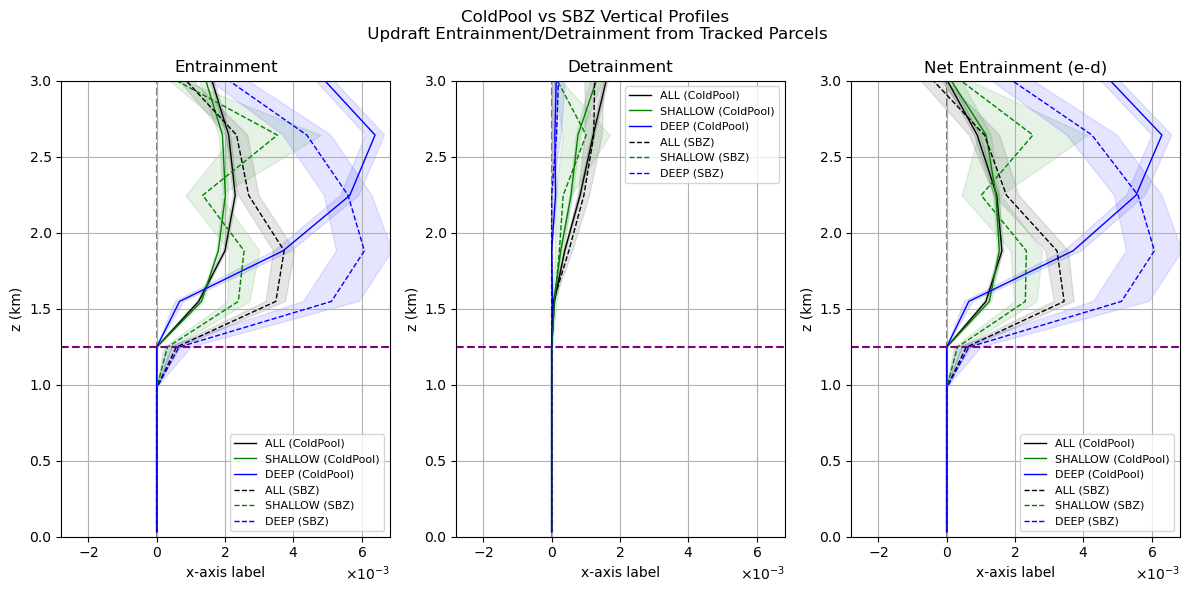

In [286]:
#PLOTTING
# type4='general'
type4='cloudy'

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Run the plotting function separately for each axis
PlotProfiles(ax1,type1=type1,type2=type2,type3='E',type4=type4[0].upper())
PlotProfiles(ax2,type1=type1,type2=type2,type3='D',type4=type4[0].upper())
PlotProfiles(ax3,type1=type1,type2=type2,type3='NET',type4=type4[0].upper())
MatchAxisLimits([ax1,ax2,ax3],dim='x')

# Optional: customize titles for each panel
ax1.set_title('Entrainment')
ax2.set_title('Detrainment')
ax3.set_title('Net Entrainment (e-d)')

plt.suptitle(f'{type1} vs {type2} Vertical Profiles\n Updraft Entrainment/Detrainment from Tracked Parcels')
plt.tight_layout()
plt.show()


In [287]:
# #PLOTTING
# fig = plt.figure(figsize=(12, 6))
# gs = fig.add_gridspec(2, 3)

# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])

# # Run the plotting function separately for each axis
# PlotProfiles(ax1,type1=type1,type2=type2,type3='e')
# PlotTwo(ax2,type1=type1,type2=type2)
# MatchAxisLimits([ax1,ax2],dim='x')

# # Optional: customize titles for each panel
# ax1.set_title('nonCloudy to Cloudy Entrainment')
# ax2.set_title('General to Cloudy Entrainment')
# plt.suptitle(f'{type1} vs {type2} Vertical Profiles\n{type3.title()} Updraft')
# plt.tight_layout()

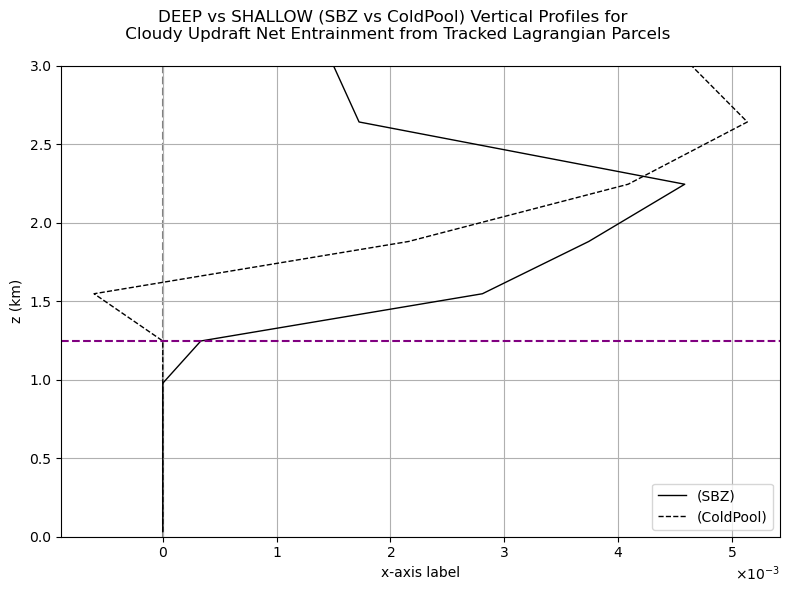

In [288]:
var = 'NET'
compute_diff('SBZ', var)
compute_diff('ColdPool', var) 

#REDUCING FOR CONFERENCE FIGURE
import matplotlib.pyplot as plt
lw=1

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (SBZ_diff_net,  'net', 'SBZ Diff'),
    (ColdPool_diff_net,  'net', 'ColdPool Diff'),
]

cutoff_height=100
# cutoff_height=7.5
# cutoff_height=2
z_cutoff=np.where(SBZ_ALL_profile_array_NET_C[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

# Set up the figure
fig = plt.figure(figsize=(8, 6))

# Create a single axis for all profiles
ax = fig.add_subplot(111)

# Loop through profiles for SBZ and ColdPool
for i, (ALL_profile, xlabel, SBZlabel) in enumerate(profiles):

    #CUT BELOW CERTAIN Z
    ALL_profile=ALL_profile[:z_cutoff]

    # Plot the profile for ALL (SBZ and ColdPool) on top of each other
    if SBZlabel == 'SBZ Diff':
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='(SBZ)',lw=lw)
    else:
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='(ColdPool)',lw=lw)
    apply_scientific_notation([ax])

if type3 in ['general','cloudy']:
    ax.set_ylim(0,3)

# Add labels and title
ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
ax.set_ylabel('z (km)')
ax.grid(True)

ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)

# Show legend
ax.legend()

#MEAN CLOUD BASE
ax.axhline(all_cloudbase,color='purple',linestyle='dashed')

# Set up the main title and adjust layout
plt.suptitle(f'DEEP vs SHALLOW (SBZ vs ColdPool) Vertical Profiles for \n {type3.title()} Updraft Net Entrainment from Tracked Lagrangian Parcels')
plt.tight_layout()

# Show plot
plt.show()


